In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [128]:
np.random.randn(5)

array([-0.26739783, -0.39850192, -0.08729211,  1.17395427,  0.17261824])

3.141592653589793


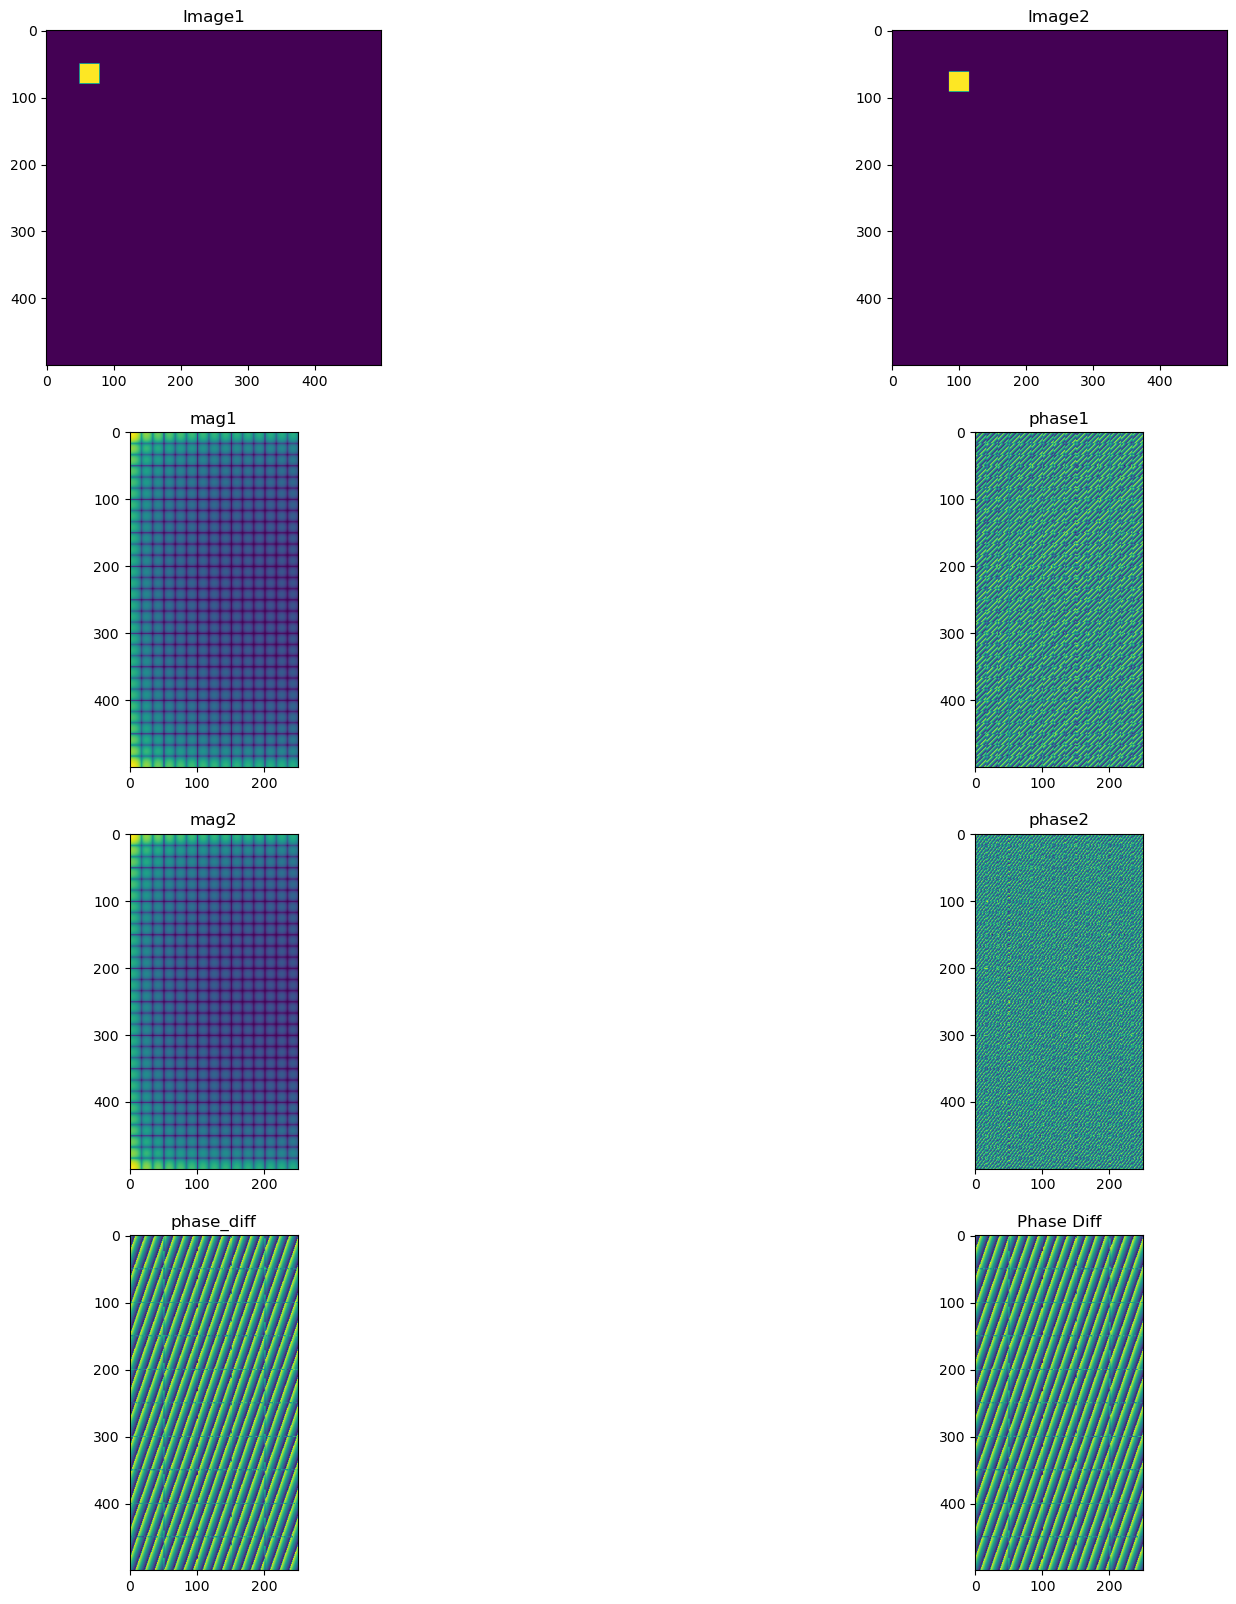

In [163]:
N = M = 500
img1 = np.zeros((500, 500))

img1 = np.zeros((N, M))
start_x, start_y = 50, 50
blob_size = 30
img1[start_y: start_y + blob_size, start_x : start_x + blob_size] = 10

# img1[::2, ::2] = 10  # checkerboard
# img1[1::2, 1::2] = 10


shifty = 12
shiftx = 35

img2 = np.roll(img1, shift=(shifty, shiftx), axis=(0, 1))
# img2 += np.random.rand(N, M) * 5
# img2 *= np.random.rand(N, M) * 5


fig, axes = plt.subplots(4, 2, figsize=(20, 20))

F1 = np.fft.rfft2(img1)
mag1, phase1 = np.abs(F1), np.angle(F1)

F2 = np.fft.rfft2(img2)
mag2, phase2 = np.abs(F2), np.angle(F2)

phase_diff = np.angle(F2 * np.conj(F1))


# Plot the two images
axes[0, 0].imshow(img1)
axes[0, 0].set_title("Image1")
axes[0, 1].imshow(img2)
axes[0, 1].set_title("Image2")

# Plot mag, phase for both under each other
axes[1, 0].imshow(np.log1p(mag1))
axes[1, 0].set_title("mag1")

axes[1, 1].imshow(phase1)
axes[1, 1].set_title("phase1")

axes[2, 0].imshow(np.log1p(mag2))
axes[2, 0].set_title("mag2")

axes[2, 1].imshow(phase2)
axes[2, 1].set_title("phase2")

# Plot phase diff
axes[3, 0].imshow(phase_diff)
axes[3, 0].set_title("phase_diff")

axes[3, 1].imshow(phase_diff)
axes[3, 1].set_title("Phase Diff")
print(phase_diff.max())

In [164]:
mid_row = phase_diff[1, :]
unwrapped_mid_row = np.unwrap(mid_row)
kx = np.arange(len(unwrapped_mid_row))
slope_x, bias_x = np.polyfit(kx, unwrapped_mid_row, 1)

mid_col = phase_diff[:, 1]
unwrapped_mid_col = np.unwrap(mid_col)
ky = np.arange(len(unwrapped_mid_col))
slope_y, bias_y = np.polyfit(ky, unwrapped_mid_col, 1)


shiftx_recovered, shifty_recovered = -N * np.array([slope_x, slope_y]) / (2 * np.pi)

shiftx_recovered, shifty_recovered

(np.float64(33.06673351637079), np.float64(12.011794956565005))

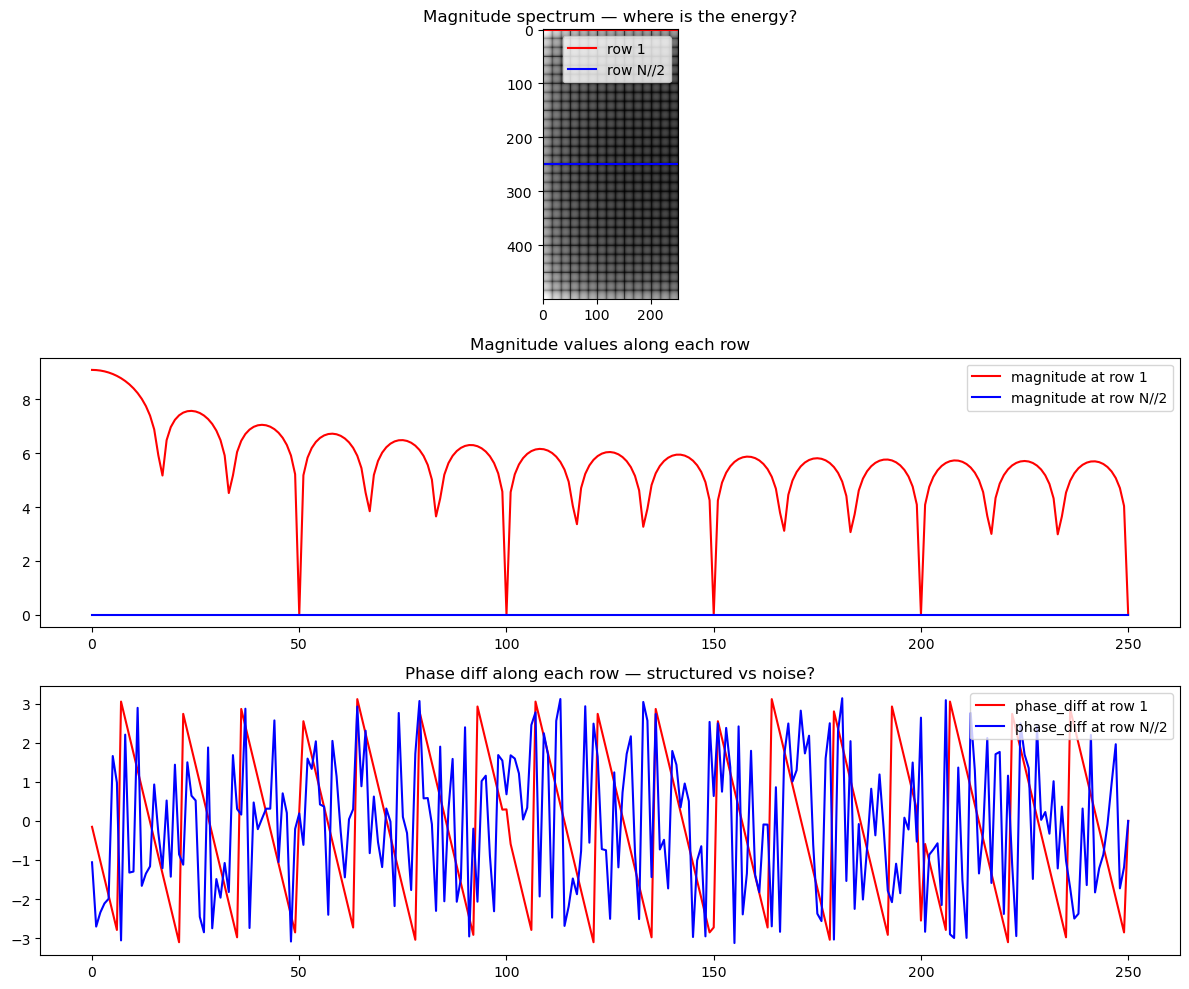

In [165]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Show the full magnitude spectrum so we can see where energy lives
axes[0].imshow(np.log1p(mag1), cmap='gray')
axes[0].axhline(y=1, color='red', label='row 1')
axes[0].axhline(y=N//2, color='blue', label='row N//2')
axes[0].set_title('Magnitude spectrum — where is the energy?')
axes[0].legend()

# Compare the actual magnitude values along those two rows
axes[1].plot(np.log1p(mag1[1, :]), color='red', label='magnitude at row 1')
axes[1].plot(np.log1p(mag1[N//2, :]), color='blue', label='magnitude at row N//2')
axes[1].set_title('Magnitude values along each row')
axes[1].legend()

# Compare the phase_diff along those two rows
axes[2].plot(phase_diff[1, :], color='red', label='phase_diff at row 1')
axes[2].plot(phase_diff[N//2, :], color='blue', label='phase_diff at row N//2')
axes[2].set_title('Phase diff along each row — structured vs noise?')
axes[2].legend()

plt.tight_layout()
plt.show()

(1.0, 211.0)

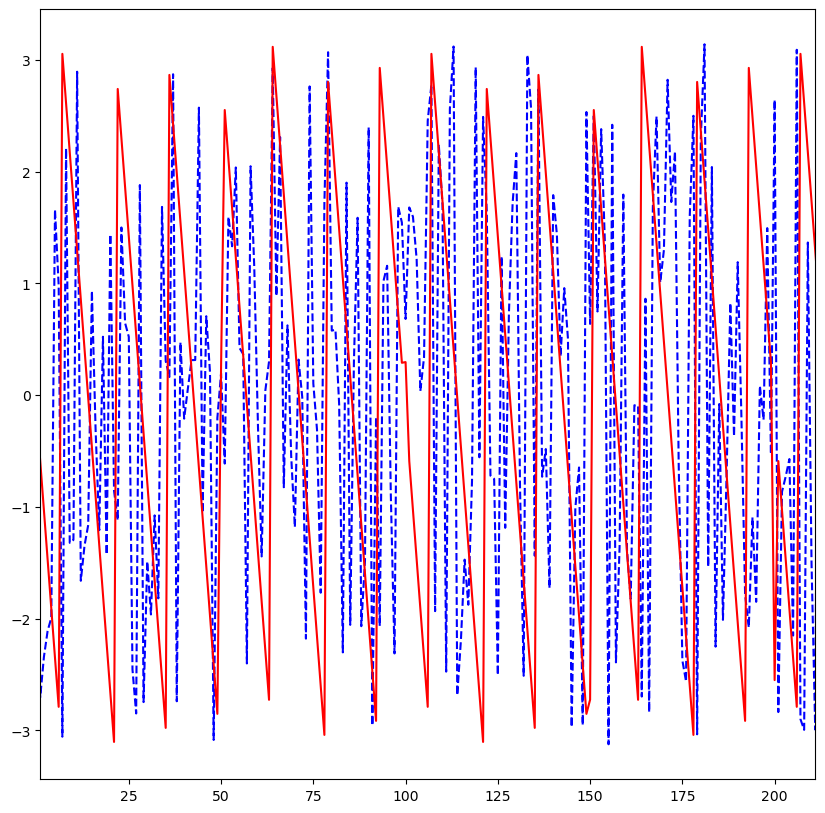

In [166]:
plt.figure(figsize=(10, 10))
plt.plot(phase_diff[N//2], 'b--')
plt.plot(phase_diff[1], 'r')
plt.xlim([1, 211])

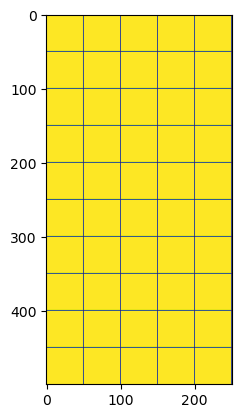

In [167]:
phase_correlation = (F2*np.conj(F1)) / (np.abs((F2*np.conj(F1))) + 1e-12)
plt.imshow(np.abs(phase_correlation))


(np.int64(12), np.int64(35))

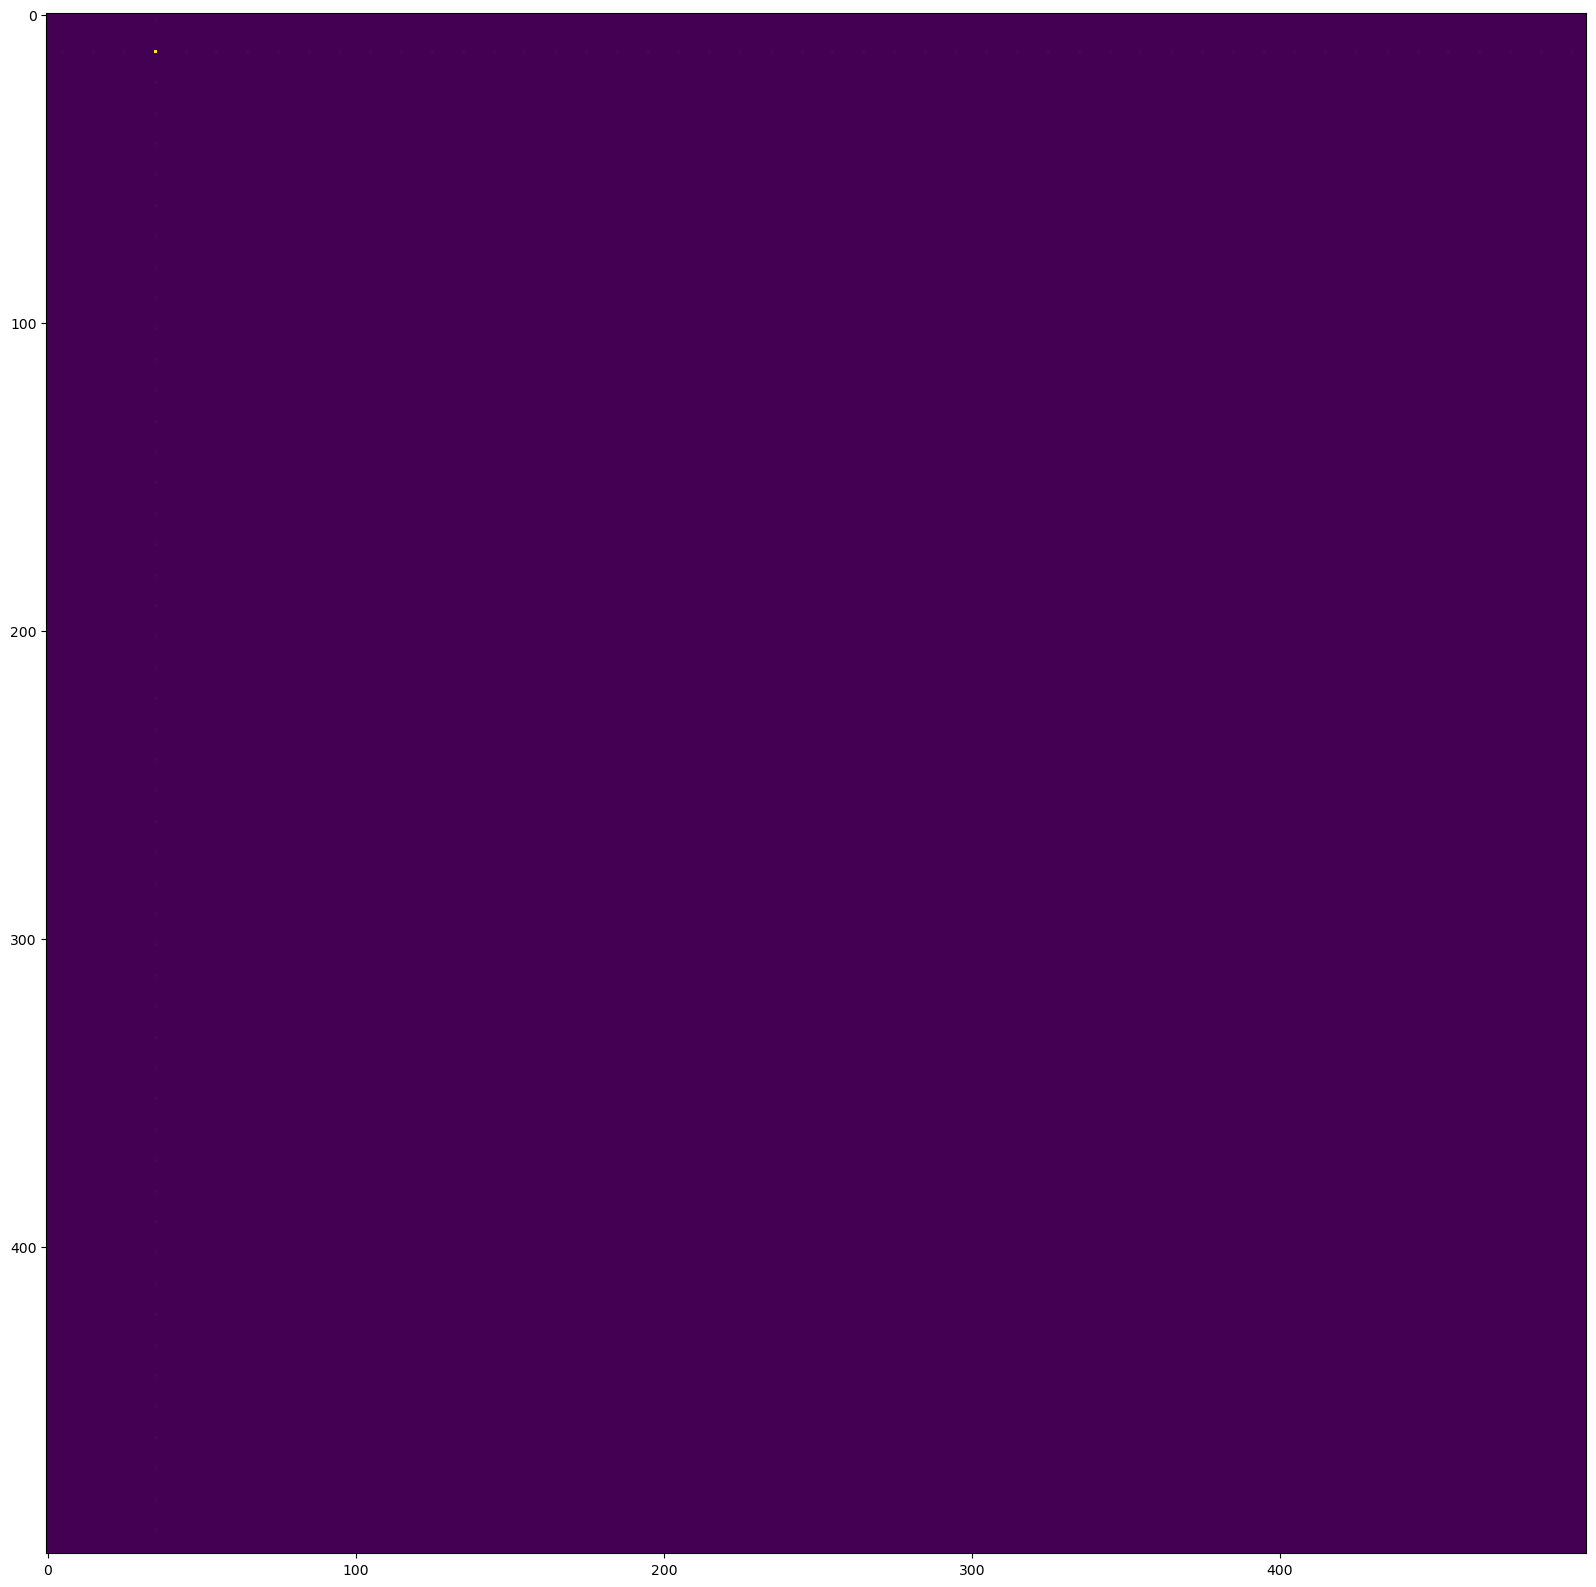

In [168]:
phase_correlation = (F2*np.conj(F1)) / (np.abs((F2*np.conj(F1))) + 1e-12)
corr = np.fft.irfft2(phase_correlation)

plt.figure(figsize=(20, 20))

plt.imshow(np.abs(corr))

np.unravel_index(np.argmax(np.abs(corr)), corr.shape)